In [ ]:
!pip install kaleido


In [ ]:
from google.colab import files
files.upload()


In [ ]:
!mkdir ~/.kaggle

In [ ]:
!cp kaggle.json ~/.kaggle/

In [ ]:
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
import kagglehub


path = kagglehub.dataset_download("mariaherrerot/aptos2019")

print("Path to dataset files:", path)

Number of train samples: 2930
Number of validation samples: 366
Number of test samples: 366
There are 2930 training images.
There are 366 validation images.
There are 366 test images.


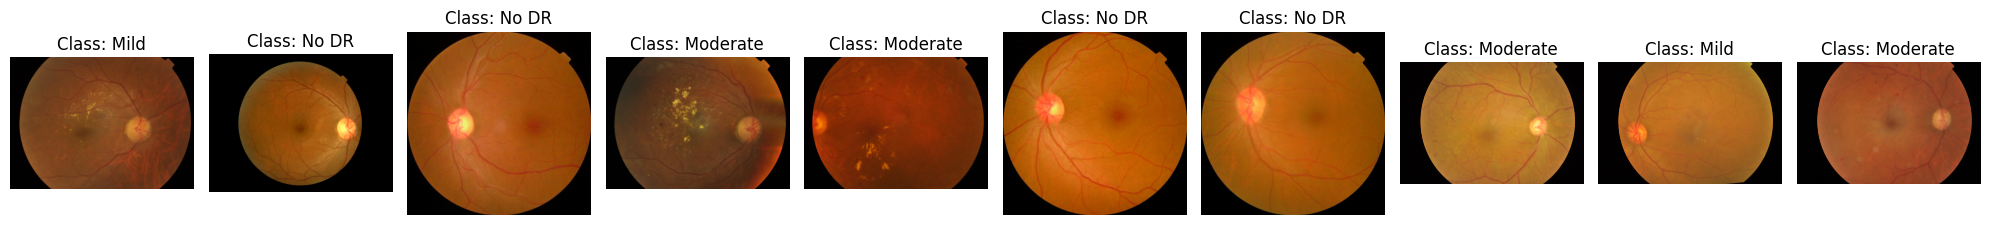

In [ ]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, cohen_kappa_score
from keras.models import Model
from keras import optimizers, applications
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import cv2
import matplotlib.image as mpimg

warnings.filterwarnings("ignore")
# Load the CSV files
train_data = pd.read_csv("/kaggle/input/aptos2019/train_1.csv")
valid_data = pd.read_csv("/kaggle/input/aptos2019/valid.csv")
test_data = pd.read_csv("/kaggle/input/aptos2019/test.csv")

# Print the number of samples in each dataset
print('Number of train samples:', train_data.shape[0])
print('Number of validation samples:', valid_data.shape[0])
print('Number of test samples:', test_data.shape[0])


import os

# Define the image directories
train_image_dir = "/kaggle/input/aptos2019/train_images/train_images"
val_image_dir = "/kaggle/input/aptos2019/val_images/val_images"
test_image_dir = "/kaggle/input/aptos2019/test_images/test_images"

# Function to count images in a directory
def count_images(directory):
    return len([file for file in os.listdir(directory) if file.endswith(('.png', '.jpg', '.jpeg'))])

# Count images in each directory
train_image_count = count_images(train_image_dir)
val_image_count = count_images(val_image_dir)
test_image_count = count_images(test_image_dir)

print(f'There are {train_image_count} training images.')
print(f'There are {val_image_count} validation images.')
print(f'There are {test_image_count} test images.')


import matplotlib.pyplot as plt
import random
import matplotlib.image as mpimg

# Class labels dictionary
class_labels = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR"
}

# Check some random images from the training set to ensure they are correctly labeled
random_samples = random.sample(list(train_data['id_code']), 10)

plt.figure(figsize=(20, 10))
for i, image_id in enumerate(random_samples):
    # Image file path
    img_path = os.path.join(train_image_dir, f"{image_id}.png")  # Adjust extension if necessary
    img = mpimg.imread(img_path)

    # Get the class label for the image
    image_class = train_data.loc[train_data['id_code'] == image_id, 'diagnosis'].values[0]
    class_name = class_labels.get(image_class, "Unknown")

    # Plot the image
    plt.subplot(1, 10, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Class: {class_name}")

plt.tight_layout()
plt.show()

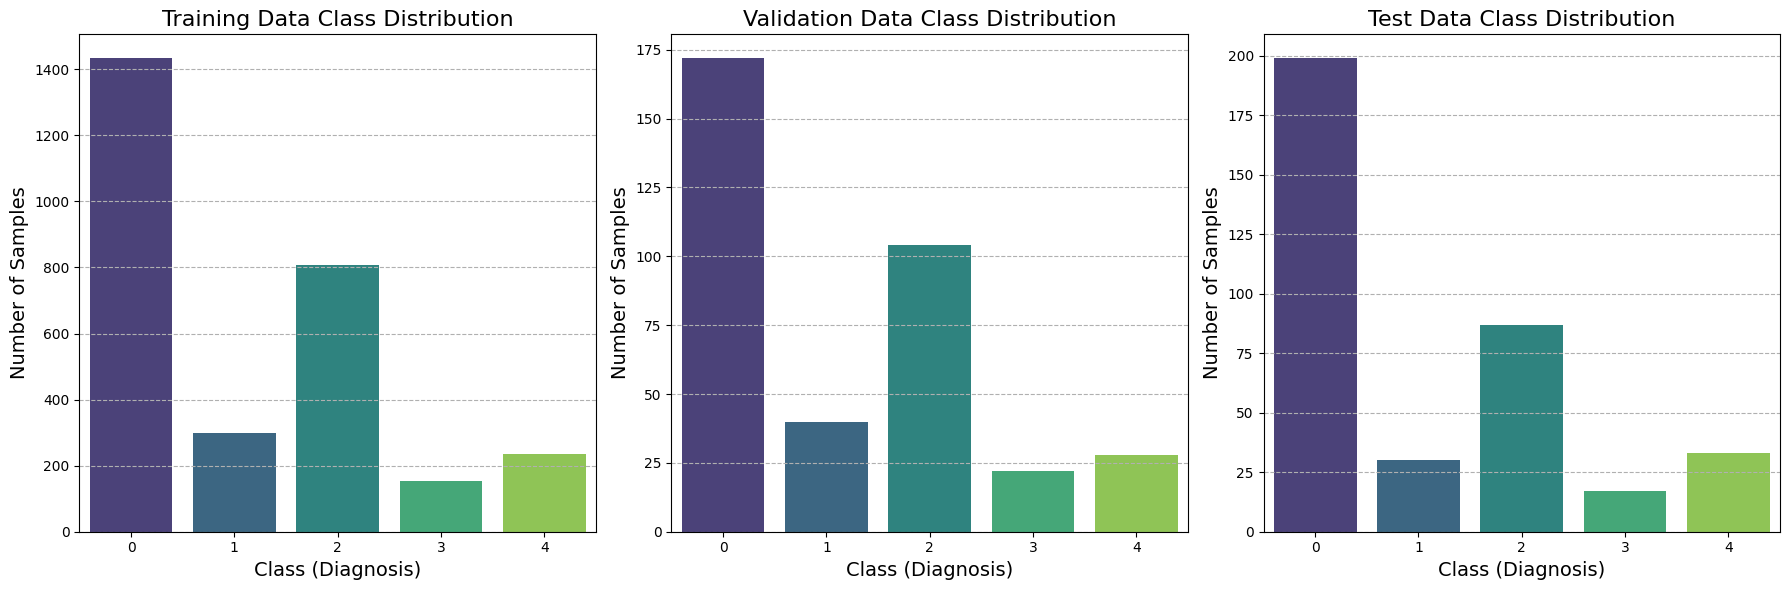

Training Data Class Distribution:
diagnosis
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: int64

Validation Data Class Distribution:
diagnosis
0    172
1     40
2    104
3     22
4     28
Name: count, dtype: int64

Test Data Class Distribution:
diagnosis
0    199
1     30
2     87
3     17
4     33
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the CSV files
train_data = pd.read_csv("/kaggle/input/aptos2019/train_1.csv")
valid_data = pd.read_csv("/kaggle/input/aptos2019/valid.csv")
test_data = pd.read_csv("/kaggle/input/aptos2019/test.csv")

# Count the occurrences of each class in the training, validation, and test datasets
train_class_counts = train_data['diagnosis'].value_counts().sort_index()
val_class_counts = valid_data['diagnosis'].value_counts().sort_index()
test_class_counts = test_data['diagnosis'].value_counts().sort_index()

# Set up the bar charts for each dataset
plt.figure(figsize=(18, 6))

# Training Data
plt.subplot(1, 3, 1)
sns.barplot(x=train_class_counts.index, y=train_class_counts.values, palette='viridis')
plt.title('Training Data Class Distribution', fontsize=16)
plt.xlabel('Class (Diagnosis)', fontsize=14)
plt.ylabel('Number of Samples', fontsize=14)
plt.xticks(ticks=train_class_counts.index, labels=train_class_counts.index)
plt.grid(axis='y', linestyle='--')

# Validation Data
plt.subplot(1, 3, 2)
sns.barplot(x=val_class_counts.index, y=val_class_counts.values, palette='viridis')
plt.title('Validation Data Class Distribution', fontsize=16)
plt.xlabel('Class (Diagnosis)', fontsize=14)
plt.ylabel('Number of Samples', fontsize=14)
plt.xticks(ticks=val_class_counts.index, labels=val_class_counts.index)
plt.grid(axis='y', linestyle='--')

# Test Data
plt.subplot(1, 3, 3)
sns.barplot(x=test_class_counts.index, y=test_class_counts.values, palette='viridis')
plt.title('Test Data Class Distribution', fontsize=16)
plt.xlabel('Class (Diagnosis)', fontsize=14)
plt.ylabel('Number of Samples', fontsize=14)
plt.xticks(ticks=test_class_counts.index, labels=test_class_counts.index)
plt.grid(axis='y', linestyle='--')


plt.tight_layout()
plt.show()

print("Training Data Class Distribution:")
print(train_class_counts)
print("\nValidation Data Class Distribution:")
print(val_class_counts)
print("\nTest Data Class Distribution:")
print(test_class_counts)

In [ ]:
!pip install imbalanced-learn

In [ ]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE

# Define image dimensions and paths
IMG_SIZE = 100
train_image_dir = "/kaggle/input/aptos2019/train_images/train_images"

# Load CSV file
train_data = pd.read_csv("/kaggle/input/aptos2019/train_1.csv")

# Preprocess the images (this function remains unchanged)
def load_and_preprocess_image(image_id):
    img_path = os.path.join(train_image_dir, f"{image_id}.png")
    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img) / 255.0
    return img_array

# Convert labels to numeric format and prepare features
X = np.array([load_and_preprocess_image(image_id) for image_id in train_data['id_code']])
y = train_data['diagnosis'].values

# Apply SMOTE to the labels
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X.reshape(X.shape[0], -1), y)  # Flatten images for SMOTE

# Convert back to the original image shape
X_resampled = X_resampled.reshape(-1, IMG_SIZE, IMG_SIZE, 3)

# Convert labels to one-hot encoded format
y_resampled = to_categorical(y_resampled, num_classes=5)

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")

Shape of X_train: (5736, 100, 100, 3)
Shape of y_train: (5736, 5)


#

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Defining the CNN model
def create_cnn_model(input_shape):
    model = Sequential()

    # First convolutional layer
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    # Second convolutional layer
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Third convolutional layer
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Flatten and fully connected layer
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))  # Add dropout to avoid overfitting

    # Output layer
    model.add(Dense(5, activation='softmax'))  # 5 classes for diagnosis

    return model


model = create_cnn_model(input_shape=(IMG_SIZE, IMG_SIZE, 3))


model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Define callbacks for early stopping and saving the best model
callbacks = [
    EarlyStopping(patience=15, monitor='val_accuracy', restore_best_weights=True),
    ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_accuracy')
]

# Train the model
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=30,
                    batch_size=32,
                    callbacks=callbacks)

Epoch 1/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 112s 612ms/step - accuracy: 0.3648 - loss: 1.4037 - val_accuracy: 0.5432 - val_loss: 1.1450
Epoch 2/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 108s 599ms/step - accuracy: 0.5090 - loss: 1.1624 - val_accuracy: 0.6018 - val_loss: 0.9885
Epoch 3/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 147s 628ms/step - accuracy: 0.5840 - loss: 1.0314 - val_accuracy: 0.6715 - val_loss: 0.8435
Epoch 4/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 105s 580ms/step - accuracy: 0.6527 - loss: 0.8716 - val_accuracy: 0.7322 - val_loss: 0.7406
Epoch 5/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 111s 615ms/step - accuracy: 0.7335 - loss: 0.6975 - val_accuracy: 0.7838 - val_loss: 0.6116
Epoch 6/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 108s 602ms/step - accuracy: 0.7776 - loss: 0.5680 - val_accuracy: 0.8145 - val_loss: 0.5068
Epoch 7/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 143s 605ms/step - accuracy: 0.8333 - loss: 0.4682 - val_accuracy: 0.8703 - val_loss: 0.3881
Epoch 8/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 111s 619ms/step - accuracy: 0.8619 -

In [ ]:
def visualize_predictions(model, X, y, num_images=20):
    plt.figure(figsize=(15,5))

    preds = model.predict(X[:num_images])
    preds = np.argmax(preds, axis=1)
    true_labels = np.argmax(y[:num_images], axis=1)

    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(X[i])
        plt.title(f"True: {true_labels[i]}\nPred: {preds[i]}")
        plt.axis('off')

    plt.show()

visualize_predictions(model, X_val, y_val)
